Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(5216, 224, 224, 3)
(5216,)
(624, 224, 224, 3)
(624,)


Text(0.5, 1.0, '1')

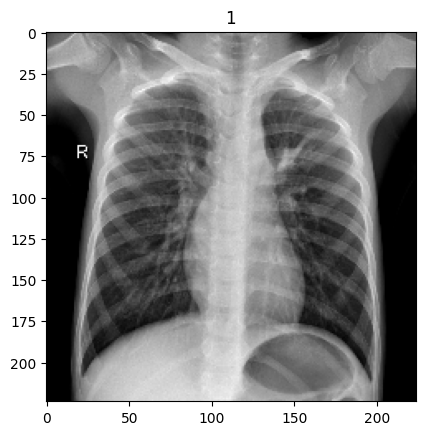

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.applications import InceptionV3
from keras.models import Model, Sequential
from keras.layers import Dense, Flatten, Dropout
from keras.callbacks import  ReduceLROnPlateau
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from google.colab import drive
drive.mount('/content/drive')

x_train = np.load("/content/drive/MyDrive/MedScanProject/penumonia224trainX.npy")
y_train = np.load("/content/drive/MyDrive/MedScanProject/penumoniatrainY.npy")
x_test= np.load("/content/drive/MyDrive/MedScanProject/penumonia224testX.npy")
y_test = np.load("/content/drive/MyDrive/MedScanProject/penumoniatestY.npy")

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)
plt.imshow(x_train[0])
plt.title(f"{y_train[0]}")

In [3]:
data_gen = ImageDataGenerator(rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')
data_gen.fit(x_train)
reduce_lr = ReduceLROnPlateau(reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',   # metric to watch
    factor=0.2,           # new_lr = lr * factor
    patience=5,           # epochs with no improvement before reducing
    min_lr=1e-6,          # lower bound for learning rate
    verbose=1             # logs the change
))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 54s 315ms/step - accuracy: 0.8743 - loss: 4.0208 - val_accuracy: 0.9584 - val_loss: 0.1201 - learning_rate: 0.0010
Epoch 2/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9451 - loss: 0.1495 - val_accuracy: 0.9556 - val_loss: 0.1103 - learning_rate: 0.0010
Epoch 3/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9525 - loss: 0.1359 - val_accuracy: 0.9502 - val_loss: 0.1260 - learning_rate: 0.0010
Epoch 4/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.9546 - loss: 0.1163 - val_accuracy: 0.9611 - val_loss: 0.0993 - learning_rate: 0.0010
Epoch 5/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.9475 - loss: 0.1193 - val_accuracy: 0.9474 - val_loss: 0.1539 - learning_rate: 0.0010
Epoch 6/100
106/106 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - accuracy: 0.9563 - loss: 0.1106 - val_accuracy: 0.9617 - val_loss: 0.0882 - learning_rate: 0.0010
Epoch 7/100
106/1

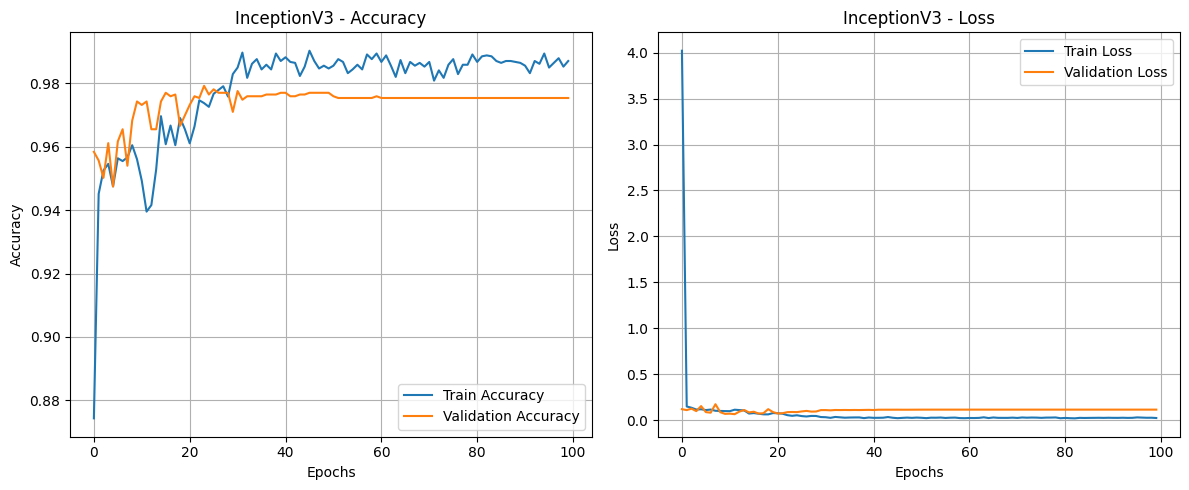

In [4]:
base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
  layer.trainable = False
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
output = Dense(len(np.unique(y_train)), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(0.001), loss='sparse_categorical_crossentropy', metrics=["accuracy"])
history = model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.35,
    callbacks=[reduce_lr]
)

test_loss, test_accuracy = model.evaluate(x_test, y_test)
test_accuracy *= 100
print(f'Test Accuracy: {test_accuracy:.2f}% | Test Loss: {test_loss:.4f}')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('InceptionV3 - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('InceptionV3 - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [5]:
model.save("/content/drive/MyDrive/MedScanProject/PenumoniaA78L2.keras")
